In [1]:
from myutils import cache, clean_all_cache, plot

from src import *
from glob import glob

from src.fisherinfo import FisherInformation, ApproxFisherInformation, FrequencyCFI

In [ ]:
@cache
def read_est(A):
    file_tree = [
        f'MLEtest(SIM)/nodelay/sin/*{A}px*',
    ]

    spade_x, spade_y = [], []
    di_x, di_y = [], []

    for file in file_tree:
        for f in glob(file):
            c = LoadEstimates(f) 
            if c.metadata.measurement == 'DI':
                di_x.append(c.metadata.ground_truth)
                di_y.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))
            elif c.metadata.measurement == 'SPADE':
                spade_x.append(c.metadata.ground_truth)
                spade_y.append(c.estimates_a.var(ddof=1) * (c.photons.mean() - qCMOS.convert2photons(c.background.mean(), 0)))

    return np.array(di_x), np.array(di_y), np.array(spade_x), np.array(spade_y)

cache hit: reading result from cache file
cache hit: reading result from cache file


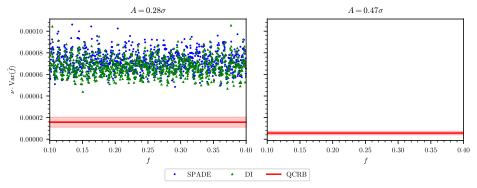

In [26]:
c1 = 'b'
c2 = 'g'

red = 'r'

width = 8.5

plt.rcParams['font.size'] = 7
plt.rcParams['savefig.bbox'] = 'tight'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(width / 2.54 * 2, width / 2.54 * 1.4 / 2), sharey=True)

for ax in (ax1, ax2):
    A = 3 if ax == ax1 else 5

    x_axis = np.linspace(0.1, 0.4, 1000)

    crb = list(1 / ApproxFisherInformation([A * DMD.PIXEL_SIZE / 2])) * 1000
    crb = np.array(crb)

    di_x, di_y, spade_x, spade_y = read_est(A)

    line1, = ax.plot(spade_x, spade_y, 
                    marker='o', linestyle='', markersize=1,
                    markeredgecolor=c1, markerfacecolor=(c1, 0.3))

    line2, = ax.plot(di_x, di_y,
                    marker='^', linestyle='', markersize=1,
                    markeredgecolor=c2, markerfacecolor=(c2, 0.3))

    line3, = ax.plot(x_axis, crb, red)
    # ax.plot(x_axis, 0.7 * crb, '-.', color=red)
    # ax.plot(x_axis, 1.3 * crb, '-.', color=red)

    # ax.grid(True, linestyle=':')

    
    ax.set_title(rf'$A = {np.round(A * DMD.PIXEL_SIZE / 2 / 103, 2)}\sigma$')

    ax.fill_between(x_axis, 0.7 * np.array(crb), 1.3 * np.array(crb), color=red, alpha=0.2)

from matplotlib.ticker import AutoMinorLocator
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y')
    ax.set_xlim(0.1, 0.4)

    ax.set_box_aspect(0.618)
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(5))
    
ax1.set_ylabel(r'$\nu\cdot{\rm Var}(\hat{f})$')
ax1.set_xlabel(r'$f$')
ax2.set_xlabel(r'$f$')

fig.legend([line1, line2, line3], ['SPADE', 'DI', 'QCRB'], ncol=3, loc='lower center', bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('ideal_sim.pdf')
plt.show()

In [48]:
data = Simulator(MetaData('DI', 0, 'frequency', 0, 0, ('mle, mle')), 'sign').gen(400)
td_ = td_estimator('DI', data[0], data[1], 'mle', False)
td_.var() * 400 / 103**2

1.180125259252722

In [25]:
c = LoadEstimates(r'MLEtest(SIM)\nodelay\sin\di_3px_f0.25_d0.npz')
td = td_estimator('DI', c.cropped_data, c.background, 'mle', False) + 3*DMD.PIXEL_SIZE/2 + 4.6/2

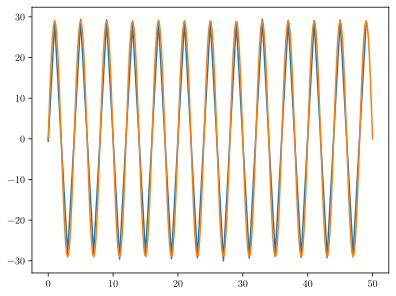

In [26]:
plot(td.mean(0))
plot((0, 50), lambda x: 3*DMD.PIXEL_SIZE/2 * np.sin(2*np.pi *0.25* x))

In [56]:
np.var([freq_estimator(td_, method='mle') for td_ in td]) * 400

6.316719415705438e-05

In [14]:
1 / ApproxFisherInformation([3 * DMD.PIXEL_SIZE / 2])

array([1.57413158e-05])

In [ ]:
6.111334368469532e

0.00015092247731734402

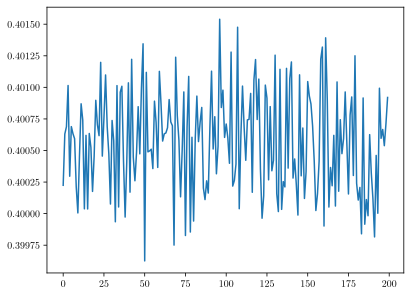

In [5]:
plot(c.estimates_a)

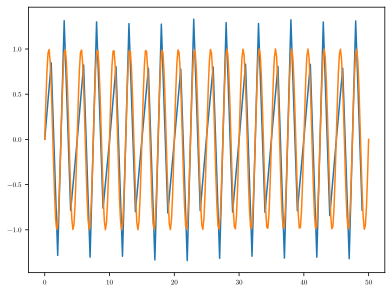

In [42]:
c = LoadEstimates(r'MLEtest(SIM)\nodelay\sin\di_3px_f0.4_d0.npz')
plot(c.time_domain.mean(0))
plot((0, 50), lambda x: np.sin(2*np.pi *0.4* x))

In [70]:
n = np.arange(50)
sample = c.time_domain[0]
N= 50

def _I(f):
    exr1 = np.sum(sample * np.cos(2*np.pi * f * n))
    exr2 = np.sum(sample * np.sin(2*np.pi * f * n) * n)

    exr3 = np.sum(sample * np.sin(2*np.pi * f * n))
    exr4 = np.sum(sample * np.cos(2*np.pi * f * n) * n)


    return - np.abs((sample * np.exp(-2j*np.pi*f*n)).sum())**2 / N, \
             2*np.pi/N * (exr1*exr2 - exr3*exr4)

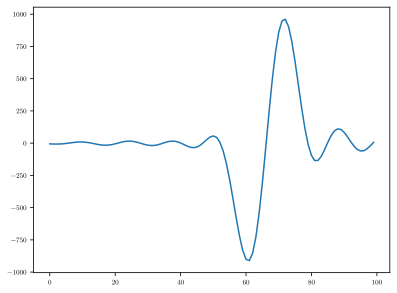

In [81]:
plot([_I(x)[1] for x in np.linspace(0.3, 0.45, 100)])
# plot([_I(x)[0] for x in np.linspace(0.3, 0.4, 100)])

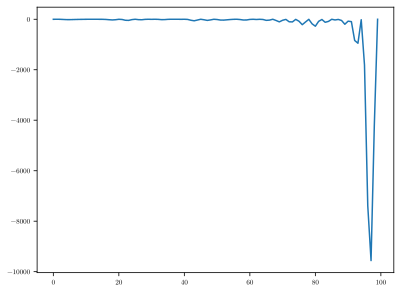

In [64]:
plot([_I(x)[0] for x in np.linspace(0.1, 0.4, 100)])

In [55]:
fim = np.array([[np.arange(50)**2, np.arange(50)], 
                [np.arange(50), np.arange(50)**0]]).sum(-1)

1/(2*(3*DMD.PIXEL_SIZE/2*np.pi/103)**2) * np.linalg.inv(fim)[0, 0]

6.111334368469532e-05